<a href="https://colab.research.google.com/github/nmansour67/skills-introduction-to-github/blob/main/Creative_Research_Clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Creative Research & Economic Development — PubMedBERT Analysis Pipeline
**Arab Academy of Science | Book Chapter**

---
## HOW TO USE THIS NOTEBOOK

| Situation | What to run |
|---|---|
| **First time ever** | Run ALL cells top to bottom |
| **Colab restarted / session lost** | Run CELL 0 only, then skip to whichever cell you need |
| **Lens enrichment already done** | Run CELL 0, then jump to CELL 10c |

**Every file is saved to Google Drive. Nothing is ever lost on restart.**

In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 0 — MASTER SETUP & SMART RECOVERY                        ║
# ║  Run this FIRST every single session — takes ~90 seconds        ║
# ║  It mounts Drive, loads all saved files, and skips anything     ║
# ║  that was already completed in a previous session.              ║
# ╚══════════════════════════════════════════════════════════════════╝

import os, sys

# ── 1. Mount Google Drive ─────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = "/content/drive/MyDrive/CreativeResearch"
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)
print(f"✅ Working directory: {PROJECT_DIR}")

# ── 2. Install libraries (silent) ────────────────────────────────
print("Installing libraries...")
os.system("pip install sentence-transformers scikit-learn pandas numpy "
          "matplotlib seaborn requests tqdm umap-learn plotly scipy -q")
print("✅ Libraries ready")

# ── 3. Import everything ─────────────────────────────────────────
import pandas as pd
import numpy as np
import requests, time
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from google.colab import userdata
print("✅ All imports successful")

# ── 4. Load Lens token ────────────────────────────────────────────
try:
    LENS_TOKEN = userdata.get("LENS_SCHOLARLY_TOKEN")
    print("✅ Lens token loaded")
except:
    LENS_TOKEN = None
    print("⚠️  Lens token not found — add it to Colab Secrets as LENS_SCHOLARLY_TOKEN")

# ── 5. List what is already saved on Drive ────────────────────────
files = os.listdir(PROJECT_DIR)
print(f"\nFiles already on Drive:")
if files:
    for f in sorted(files):
        kb = os.path.getsize(f) / 1024
        print(f"   {f}  ({kb:.0f} KB)")
else:
    print("   (none yet — first run)")

# ── 6. Smart reload — load whatever already exists ────────────────
df = None
embeddings = None
model = None
N_CLUSTERS = 30

# Load the best available corpus version
if "pubmed_corpus_enriched.csv" in files:
    df = pd.read_csv("pubmed_corpus_enriched.csv")
    print(f"\n✅ Loaded ENRICHED corpus: {len(df)} articles")
elif "pubmed_corpus.csv" in files:
    df = pd.read_csv("pubmed_corpus.csv")
    print(f"\n✅ Loaded plain corpus: {len(df)} articles")
else:
    print("\n⚠️  No corpus found → run CELL 2 and CELL 3")

# Load embeddings
if "pubmed_embeddings.npy" in files:
    embeddings = np.load("pubmed_embeddings.npy")
    print(f"✅ Loaded embeddings: {embeddings.shape}")
else:
    print("⚠️  No embeddings found → run CELL 5")

# Re-apply clustering if both df and embeddings exist
if df is not None and embeddings is not None:
    kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
    df["cluster"] = kmeans.fit_predict(embeddings)

    # Re-apply TF-IDF labels
    CUSTOM_STOPS = [
        "ai","artificial","intelligence","artificial intelligence",
        "machine","learning","machine learning","deep","deep learning",
        "health","healthcare","health care","care","medical","clinical",
        "patient","patients","data","model","models","study","studies",
        "use","used","using","based","approach","methods","method",
        "result","results","performance","accuracy","dataset","system",
        "proposed","review","paper","algorithm","neural","network",
        "training","test","trained","prediction","predicted",
        "aim","aims","objective","background","conclusion",
        "introduction","abstract","significant","analysis",
        "developed","development","improve","improvement","novel",
        "demonstrate","demonstrated","shows","showed","high","low",
        "large","small","new","current","recent","potential",
    ]
    import scipy.sparse as sp
    vec = TfidfVectorizer(
        max_features=80000, stop_words="english",
        ngram_range=(1,3), sublinear_tf=True, min_df=3, max_df=0.6
    )
    tfidf_matrix = vec.fit_transform(df["full_text"])
    feature_names = vec.get_feature_names_out()
    custom_stop_set = set(CUSTOM_STOPS)
    zero_cols = [i for i, f in enumerate(feature_names) if f in custom_stop_set]
    tfidf_lil = sp.lil_matrix(tfidf_matrix)
    for col in zero_cols:
        tfidf_lil[:, col] = 0
    tfidf_matrix = tfidf_lil.tocsr()
    cluster_names = {}
    for cid in range(N_CLUSTERS):
        mask = df["cluster"] == cid
        ctfidf = tfidf_matrix[mask.to_numpy()].mean(axis=0)
        top_idx = np.asarray(ctfidf).flatten().argsort()[-5:][::-1]
        cluster_names[cid] = " | ".join([feature_names[i] for i in top_idx])
    df["cluster_name"] = df["cluster"].map(cluster_names)
    print(f"✅ Clusters and labels applied ({N_CLUSTERS} clusters)")

# Load PubMedBERT model
print("\nLoading PubMedBERT model (~60 seconds)...")
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("neuml/pubmedbert-base-embeddings")
print("✅ PubMedBERT model ready")

print("\n" + "="*50)
print("✅ CELL 0 COMPLETE — ready to continue")
print("="*50)

Mounted at /content/drive
✅ Working directory: /content/drive/MyDrive/CreativeResearch
Installing libraries...
✅ Libraries ready
✅ All imports successful
✅ Lens token loaded

Files already on Drive:
   (none yet — first run)

⚠️  No corpus found → run CELL 2 and CELL 3
⚠️  No embeddings found → run CELL 5

Loading PubMedBERT model (~60 seconds)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ PubMedBERT model ready

✅ CELL 0 COMPLETE — ready to continue


---
## PHASE 1 — DATA COLLECTION
*(Skip if pubmed_corpus.csv already exists on Drive)*

In [2]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — FETCH PUBMED ARTICLE IDs                             ║
# ║  Skip if pubmed_corpus.csv already exists on Drive              ║
# ╚══════════════════════════════════════════════════════════════════╝

if "pubmed_corpus.csv" in os.listdir(PROJECT_DIR):
    print("✅ pubmed_corpus.csv already exists on Drive — skipping fetch")
    print("   Delete the file from Drive if you want to re-fetch from scratch")
else:
    SEARCH_QUERY = "artificial intelligence[MeSH] AND healthcare[MeSH]"
    START_YEAR   = "2020"
    END_YEAR     = "2025"
    MAX_RESULTS  = 5000
    BASE_URL     = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/"

    print(f"Searching PubMed: {SEARCH_QUERY}")
    params = {
        "db": "pubmed", "term": SEARCH_QUERY,
        "datetype": "pdat", "mindate": START_YEAR, "maxdate": END_YEAR,
        "retmax": MAX_RESULTS, "retmode": "json"
    }
    response = requests.get(BASE_URL + "esearch.fcgi", params=params)
    data = response.json()
    pmids = data["esearchresult"]["idlist"]
    total = data["esearchresult"]["count"]
    print(f"✅ Total articles found in PubMed: {total}")
    print(f"✅ Fetching first {len(pmids)} IDs")

Searching PubMed: artificial intelligence[MeSH] AND healthcare[MeSH]
✅ Total articles found in PubMed: 4983
✅ Fetching first 4983 IDs


In [3]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — FETCH ABSTRACTS FROM PUBMED                          ║
# ║  Skip if pubmed_corpus.csv already exists on Drive              ║
# ╚══════════════════════════════════════════════════════════════════╝

if "pubmed_corpus.csv" in os.listdir(PROJECT_DIR):
    print("✅ pubmed_corpus.csv already exists on Drive — skipping")
else:
    import xml.etree.ElementTree as ET
    BASE_URL = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/"

    papers = []
    batch_size = 200
    for i in tqdm(range(0, len(pmids), batch_size), desc="Fetching abstracts"):
        batch = pmids[i:i+batch_size]
        params = {
            "db": "pubmed", "id": ",".join(batch),
            "rettype": "xml", "retmode": "xml"
        }
        response = requests.get(BASE_URL + "efetch.fcgi", params=params)
        root = ET.fromstring(response.content)
        for article in root.findall(".//PubmedArticle"):
            pmid_el     = article.find(".//PMID")
            title_el    = article.find(".//ArticleTitle")
            abstract_el = article.find(".//AbstractText")
            year_el     = article.find(".//PubDate/Year")
            pmid_val    = pmid_el.text    if pmid_el     is not None else ""
            title_val   = title_el.text   if title_el    is not None else ""
            abstract_val= abstract_el.text if abstract_el is not None else ""
            year_val    = year_el.text    if year_el     is not None else ""
            if title_val and abstract_val:
                papers.append({
                    "pmid": pmid_val, "title": title_val,
                    "abstract": abstract_val, "year": year_val,
                    "full_text": title_val + ". " + abstract_val
                })
        time.sleep(0.4)

    df = pd.DataFrame(papers)
    df.to_csv("pubmed_corpus.csv", index=False)
    print(f"\n✅ Fetched {len(df)} articles with abstracts")
    print(f"✅ Saved to Drive: pubmed_corpus.csv")
    print(df[["pmid","year","title"]].head(5))

Fetching abstracts: 100%|██████████| 25/25 [00:53<00:00,  2.13s/it]



✅ Fetched 4522 articles with abstracts
✅ Saved to Drive: pubmed_corpus.csv
       pmid  year                                              title
0  42008130  2025                      Diagnosis in the digital age.
1  41971215  2025  The Evolution of Vision Therapy Software and I...
2  41938540  2025  Evaluating sentiment analysis models in health...
3  41936425  2026  Ally, the pioneering abortion chatbot: Capturi...
4  41891306  2026  An interview study on socially assistive robot...


---
## PHASE 2 — PUBMEDBERT EMBEDDING
*(Skip if pubmed_embeddings.npy already exists on Drive — takes 10-15 min)*

In [6]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — EMBED ALL ABSTRACTS WITH PUBMEDBERT                  ║
# ║  Skip if pubmed_embeddings.npy already exists on Drive          ║
# ║  ⏱ Takes 10–15 minutes on GPU — runs only once ever            ║
# ╚══════════════════════════════════════════════════════════════════╝

if "pubmed_embeddings.npy" in os.listdir(PROJECT_DIR):
    print("✅ pubmed_embeddings.npy already exists on Drive — skipping")
    print(f"   Shape: {embeddings.shape}")
else:
    if df is None:
        df = pd.read_csv("pubmed_corpus.csv")

    texts = df["full_text"].tolist()
    print(f"Embedding {len(texts)} articles with PubMedBERT...")
    print("This takes 10–15 minutes. Leave the tab open.\n")

    # Determine device: Use GPU if available, otherwise CPU
    import torch
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    embeddings = model.encode(
        texts,
        batch_size=64,
        show_progress_bar=True,
        device=device
    )
    np.save("pubmed_embeddings.npy", embeddings)
    print(f"\n✅ Embeddings shape: {embeddings.shape}")
    print("✅ Saved to Drive: pubmed_embeddings.npy")

Embedding 4522 articles with PubMedBERT...
This takes 10–15 minutes. Leave the tab open.

Using device: cpu


Batches:   0%|          | 0/71 [00:00<?, ?it/s]


✅ Embeddings shape: (4522, 768)
✅ Saved to Drive: pubmed_embeddings.npy


---
## PHASE 3 — CLUSTERING & LABELLING

Testing cluster counts to find optimal K...
(Testing K = 15, 20, 25, 30, 35, 40)

  K= 15 → Silhouette Score: 0.0269
  K= 20 → Silhouette Score: 0.0276
  K= 25 → Silhouette Score: 0.0316
  K= 30 → Silhouette Score: 0.0266
  K= 35 → Silhouette Score: 0.0284
  K= 40 → Silhouette Score: 0.0262

✅ Best K by silhouette score: 25


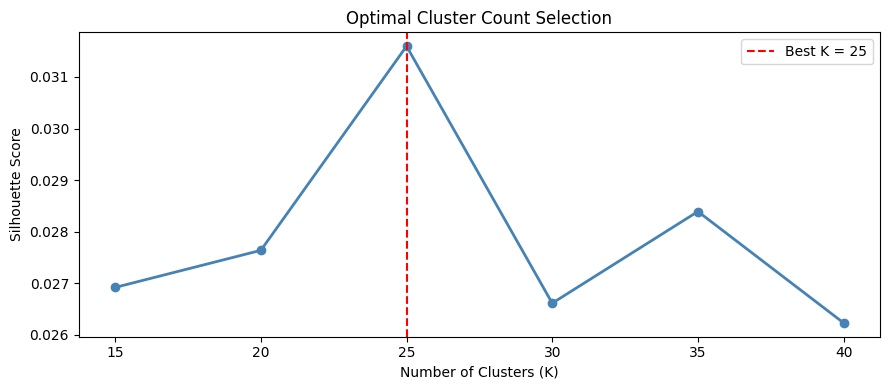


✅ Final clustering complete with K=25
cluster
0     213
1     227
2     241
3     368
4     190
5     185
6     263
7     164
8     261
9     153
10    222
11    111
12    107
13    152
14    102
15    220
16    154
17    191
18    129
19    245
20     48
21    140
22    167
23     93
24    176
Name: count, dtype: int64


In [7]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — K-MEANS CLUSTERING WITH OPTIMAL K SELECTION          ║
# ╚══════════════════════════════════════════════════════════════════╝

from sklearn.metrics import silhouette_score

print("Testing cluster counts to find optimal K...")
print("(Testing K = 15, 20, 25, 30, 35, 40)\n")

k_range = range(15, 41, 5)
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=5)
    labels = km.fit_predict(embeddings)
    score = silhouette_score(embeddings, labels, sample_size=1000, random_state=42)
    sil_scores.append(score)
    print(f"  K={k:3d} → Silhouette Score: {score:.4f}")

best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f"\n✅ Best K by silhouette score: {best_k}")

# Plot silhouette scores
plt.figure(figsize=(9, 4))
plt.plot(list(k_range), sil_scores, marker="o", color="steelblue", linewidth=2)
plt.axvline(best_k, color="red", linestyle="--", label=f"Best K = {best_k}")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Optimal Cluster Count Selection")
plt.legend()
plt.tight_layout()
plt.savefig("optimal_k.png", dpi=150)
plt.show()

# Run final clustering
N_CLUSTERS = best_k
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(embeddings)
print(f"\n✅ Final clustering complete with K={N_CLUSTERS}")
print(df["cluster"].value_counts().sort_index())

In [8]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — TF-IDF CLUSTER LABELLING (IMPROVED)                  ║
# ║  Uses custom stop-word list to avoid generic AI/health labels   ║
# ╚══════════════════════════════════════════════════════════════════╝

import scipy.sparse as sp

CUSTOM_STOPS = [
    "ai","artificial","intelligence","artificial intelligence",
    "machine","learning","machine learning","deep","deep learning",
    "health","healthcare","health care","care","medical","clinical",
    "patient","patients","data","model","models","study","studies",
    "use","used","using","based","approach","methods","method",
    "result","results","performance","accuracy","dataset","system",
    "proposed","review","paper","algorithm","neural","network",
    "training","test","trained","prediction","predicted",
    "aim","aims","objective","background","conclusion",
    "introduction","abstract","significant","analysis",
    "developed","development","improve","improvement","novel",
    "demonstrate","demonstrated","shows","showed","high","low",
    "large","small","new","current","recent","potential",
]

vectorizer = TfidfVectorizer(
    max_features=80000,
    stop_words="english",
    ngram_range=(1, 3),
    sublinear_tf=True,
    min_df=3,
    max_df=0.6,
)
tfidf_matrix = vectorizer.fit_transform(df["full_text"])
feature_names = vectorizer.get_feature_names_out()

# Zero out custom stop words
custom_stop_set = set(CUSTOM_STOPS)
zero_cols = [i for i, f in enumerate(feature_names) if f in custom_stop_set]
tfidf_lil = sp.lil_matrix(tfidf_matrix)
for col in zero_cols:
    tfidf_lil[:, col] = 0
tfidf_matrix = tfidf_lil.tocsr()

cluster_names = {}
for cid in range(N_CLUSTERS):
    mask = df["cluster"] == cid
    ctfidf = tfidf_matrix[mask.to_numpy()].mean(axis=0)
    top_idx = np.asarray(ctfidf).flatten().argsort()[-5:][::-1]
    top_words = [feature_names[i] for i in top_idx]
    cluster_names[cid] = " | ".join(top_words)
    print(f"Cluster {cid:2d} ({mask.sum():4d} papers): {cluster_names[cid]}")

df["cluster_name"] = df["cluster"].map(cluster_names)
print("\n✅ Cluster labelling complete")

Cluster  0 ( 213 papers): drug | treatment | therapy | polypharmacy | decision
Cluster  1 ( 227 papers): predict | adherence | predicting | risk | factors
Cluster  2 ( 241 papers): ethical | ethics | legal | artificial intelligence ai | intelligence ai
Cluster  3 ( 368 papers): intelligence ai | artificial intelligence ai | medicine | applications | challenges
Cluster  4 ( 190 papers): ml | learning ml | machine learning ml | decision | applications
Cluster  5 ( 185 papers): artificial intelligence ai | intelligence ai | diagnosis | cancer | diagnostic
Cluster  6 ( 263 papers): digital | digital health | technologies | technology | medicine
Cluster  7 ( 164 papers): chatgpt | chatbots | chatbot | questions | ai chatbots
Cluster  8 ( 261 papers): artificial intelligence ai | intelligence ai | decision | support | perspectives
Cluster  9 ( 153 papers): remote | surgery | robotic | surgical | telemedicine
Cluster 10 ( 222 papers): iot | smart | monitoring | devices | things
Cluster 11 ( 1

In [9]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — CLUSTER INTERPRETATION REPORT                        ║
# ║  Shows top keywords + 3 most representative papers per cluster  ║
# ╚══════════════════════════════════════════════════════════════════╝

print("=" * 70)
print("CLUSTER INTERPRETATION REPORT")
print("=" * 70)

report_rows = []

for cid in range(N_CLUSTERS):
    mask = df["cluster"] == cid
    cluster_df = df[mask].copy()
    n = len(cluster_df)
    label = cluster_names[cid]

    # Find 3 papers closest to cluster centroid
    cluster_embs = embeddings[mask.to_numpy()]
    centroid = cluster_embs.mean(axis=0, keepdims=True)
    sims = cosine_similarity(centroid, cluster_embs)[0]
    top3_idx = sims.argsort()[-3:][::-1]
    rep_titles = cluster_df.iloc[top3_idx]["title"].tolist()

    print(f"\nCLUSTER {cid:2d} — {n} papers")
    print(f"  Keywords: {label}")
    print(f"  Representative papers:")
    for t in rep_titles:
        print(f"    • {t[:95]}")

    report_rows.append({
        "cluster_id": cid, "n_papers": n, "keywords": label,
        "rep_paper_1": rep_titles[0] if len(rep_titles) > 0 else "",
        "rep_paper_2": rep_titles[1] if len(rep_titles) > 1 else "",
        "rep_paper_3": rep_titles[2] if len(rep_titles) > 2 else "",
    })

print("\n" + "=" * 70)
report_df = pd.DataFrame(report_rows)
report_df.to_csv("cluster_report.csv", index=False)
print("✅ Cluster report saved to Drive: cluster_report.csv")

CLUSTER INTERPRETATION REPORT

CLUSTER  0 — 213 papers
  Keywords: drug | treatment | therapy | polypharmacy | decision
  Representative papers:
    • Patient-Centered Clinical Decision Support-Where Are We and Where to Next?
    • Quadruple Decision Making for Parkinson's Disease Patients: Combining Expert Opinion, Patient P
    • BPM Support for Patient-Centred Clinical Pathways in Chronic Diseases.

CLUSTER  1 — 227 papers
  Keywords: predict | adherence | predicting | risk | factors
  Representative papers:
    • Predictive models of medication non-adherence risks of patients with T2D based on multiple mach
    • Potentially inappropriate polypharmacy is an important predictor of 30-day emergency hospitalis
    • Using Machine Learning to Predict Treatment Adherence in Patients on Medication for Opioid Use 

CLUSTER  2 — 241 papers
  Keywords: ethical | ethics | legal | artificial intelligence ai | intelligence ai
  Representative papers:
    • Pitfalls of Artificial Intelligence i

---
## PHASE 4 — VISUALISATION

In [10]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — UMAP 2D VISUALISATION                                ║
# ║  Interactive scatter plot of all papers coloured by cluster     ║
# ╚══════════════════════════════════════════════════════════════════╝

import umap
import plotly.express as px

print("Reducing to 2D with UMAP (~2 minutes)...")
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
coords_2d = reducer.fit_transform(embeddings)

df["x"] = coords_2d[:, 0]
df["y"] = coords_2d[:, 1]

fig = px.scatter(
    df, x="x", y="y",
    color="cluster_name",
    hover_data=["pmid", "year", "title"],
    title="PubMed Research Clusters — PubMedBERT Embeddings",
    width=1100, height=700
)
fig.show()
print("✅ UMAP visualisation complete")
print("   Tip: hover over dots to read paper titles")

Reducing to 2D with UMAP (~2 minutes)...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✅ UMAP visualisation complete
   Tip: hover over dots to read paper titles


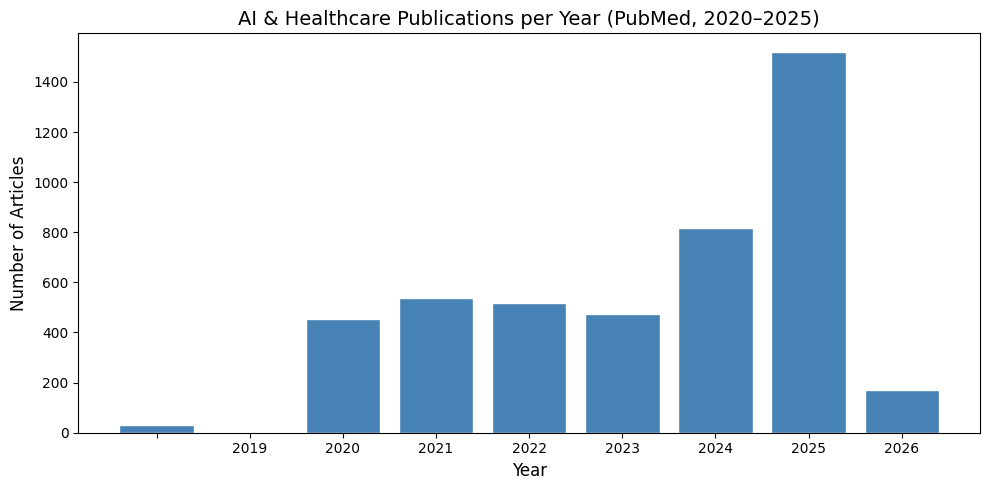

✅ Saved: publications_per_year.png

Year counts:
year
          32
2019       3
2020     452
2021     537
2022     519
2023     475
2024     816
2025    1518
2026     170


In [11]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — PUBLICATION TREND CHART (Bonus A)                    ║
# ╚══════════════════════════════════════════════════════════════════╝

year_counts = df["year"].value_counts().sort_index()
plt.figure(figsize=(10, 5))
plt.bar(year_counts.index, year_counts.values, color="steelblue", edgecolor="white")
plt.title("AI & Healthcare Publications per Year (PubMed, 2020–2025)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Articles", fontsize=12)
plt.tight_layout()
plt.savefig("publications_per_year.png", dpi=150)
plt.show()
print("✅ Saved: publications_per_year.png")
print("\nYear counts:")
print(year_counts.to_string())

In [12]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — CLUSTER SIZE RANKING (Bonus B)                       ║
# ╚══════════════════════════════════════════════════════════════════╝

cluster_summary = df.groupby("cluster_name").agg(
    n_papers=("pmid", "count"),
    years_range=("year", lambda x: f"{x.min()}–{x.max()}")
).sort_values("n_papers", ascending=False).reset_index()

print("=== RESEARCH DOMAIN SIZE RANKING ===\n")
print(cluster_summary.to_string(index=False))
cluster_summary.to_csv("cluster_summary.csv", index=False)
print("\n✅ Saved: cluster_summary.csv")

=== RESEARCH DOMAIN SIZE RANKING ===

                                                                             cluster_name  n_papers years_range
      intelligence ai | artificial intelligence ai | medicine | applications | challenges       368       –2026
                          digital | digital health | technologies | technology | medicine       263       –2026
         artificial intelligence ai | intelligence ai | decision | support | perspectives       261   2020–2026
                              classification | detection | features | disease | framework       245   2020–2026
                  ethical | ethics | legal | artificial intelligence ai | intelligence ai       241   2020–2026
                                        predict | adherence | predicting | risk | factors       227       –2026
                                              iot | smart | monitoring | devices | things       222   2020–2026
      equity | artificial intelligence ai | intelligence ai | chal

In [13]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — SEMANTIC SEARCH (Bonus C)                           ║
# ║  Finds papers most similar to commercialisation queries         ║
# ╚══════════════════════════════════════════════════════════════════╝

queries = [
    "AI startup commercialized into a healthcare product",
    "machine learning clinical decision support system deployed",
    "deep learning diagnostic tool economic impact",
    "natural language processing hospital workflow automation",
    "AI model reducing healthcare costs improving efficiency"
]

print("=" * 70)
for q in queries:
    qemb = model.encode([q])
    scores = cosine_similarity(qemb, embeddings)[0]
    df["score"] = scores
    top3 = df.nlargest(3, "score")[["year", "pmid", "title", "score"]]
    print(f"\nQUERY: '{q}'")
    for _, row in top3.iterrows():
        print(f"  [{row['year']}] {row['title'][:90]}")
        print(f"           PMID: {row['pmid']} | Score: {row['score']:.3f}")
print("=" * 70)


QUERY: 'AI startup commercialized into a healthcare product'
  [2021] Rising to the challenge of bias in health care AI.
           PMID: 34893774 | Score: 0.568
  [2020] Commercial Adoption of AI in the Healthcare Sector: An Exploratory Analysis of S&P500 Comp
           PMID: 32570357 | Score: 0.540
  [2023] [The Concept of a Healthcare AI Platform].
           PMID: 37317596 | Score: 0.536

QUERY: 'machine learning clinical decision support system deployed'
  [2023] Machine learning-based clinical decision support systems for pregnancy care: A systematic 
           PMID: 36907027 | Score: 0.760
  [2022] A Graphical Toolkit for Longitudinal Dataset Maintenance and Predictive Model Training in 
           PMID: 35172371 | Score: 0.732
  [2023] Machine Learning Based Risk Prediction for Major Adverse Cardiovascular Events for ELGA-Au
           PMID: 37172147 | Score: 0.725

QUERY: 'deep learning diagnostic tool economic impact'
  [2026] Scoping review on the economic aspects of mach

---
## PHASE 5 — LENS.ORG SCHOLARLY ENRICHMENT
*(Skip Cells 11–13 if pubmed_corpus_enriched.csv already exists on Drive)*

In [14]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — TEST LENS.ORG CONNECTION                            ║
# ╚══════════════════════════════════════════════════════════════════╝

if LENS_TOKEN is None:
    print("❌ LENS_TOKEN not found")
    print("   Go to Colab left sidebar → 🔑 Secrets")
    print("   Add secret: name=LENS_SCHOLARLY_TOKEN, value=your token")
else:
    url = "https://api.lens.org/scholarly/search"
    headers = {"Authorization": f"Bearer {LENS_TOKEN}", "Content-Type": "application/json"}
    body = {
        "query": {"match": {"title": "artificial intelligence healthcare"}},
        "size": 1,
        "include": ["title", "scholarly_citations_count"]
    }
    r = requests.post(url, json=body, headers=headers, timeout=15)
    if r.status_code == 200:
        result = r.json()["data"][0]
        print("✅ Lens.org connection successful")
        print(f"   Sample title: {result.get('title', '')}")
        print(f"   Sample citations: {result.get('scholarly_citations_count', 0)}")
    else:
        print(f"❌ Connection failed: {r.status_code}")
        print(f"   {r.text}")

✅ Lens.org connection successful
   Sample title: Artificial Intelligence in Healthcare
   Sample citations: 1


In [15]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 12 — ENRICH CORPUS WITH LENS.ORG CITATION DATA           ║
# ║  ⏱ Takes 60–90 minutes. Saves progress every 500 papers.       ║
# ║  If interrupted: re-run this cell — it resumes automatically.  ║
# ║  Skip entirely if pubmed_corpus_enriched.csv is on Drive.       ║
# ╚══════════════════════════════════════════════════════════════════╝

CHECKPOINT_FILE = "lens_checkpoint.csv"
ENRICHED_FILE   = "pubmed_corpus_enriched.csv"

if ENRICHED_FILE in os.listdir(PROJECT_DIR):
    print("✅ pubmed_corpus_enriched.csv already exists on Drive — skipping")
    print("   Loading enriched corpus...")
    df = pd.read_csv(ENRICHED_FILE)
    print(f"   {len(df)} articles loaded")
    print(f"   Average citations: {df['citation_count'].mean():.1f}")
    print(f"   Open access rate:  {df['open_access'].mean()*100:.1f}%")

else:
    def get_lens_metadata(pmid, token, title_fallback=""):
        url = "https://api.lens.org/scholarly/search"
        headers = {"Authorization": f"Bearer {token}", "Content-Type": "application/json"}
        # Primary: search by PMID
        body = {
            "query": {"term": {"external_ids.value": str(pmid)}},
            "size": 1,
            "include": ["lens_id","title","scholarly_citations_count",
                        "open_access","year_published","source.publisher"]
        }
        try:
            r = requests.post(url, json=body, headers=headers, timeout=15)
            if r.status_code == 200 and r.json().get("total", 0) > 0:
                rec = r.json()["data"][0]
                return {
                    "lens_id":        rec.get("lens_id", ""),
                    "citation_count": rec.get("scholarly_citations_count", 0),
                    "open_access":    rec.get("open_access", {}).get("is_oa", False),
                    "publisher":      rec.get("source", {}).get("publisher", ""),
                    "lens_year":      rec.get("year_published", ""),
                    "found": True
                }
            # Fallback: title search
            if title_fallback:
                body2 = {
                    "query": {"match": {"title": title_fallback[:80]}},
                    "size": 1,
                    "include": ["lens_id","scholarly_citations_count","open_access"]
                }
                r2 = requests.post(url, json=body2, headers=headers, timeout=15)
                if r2.status_code == 200 and r2.json().get("total", 0) > 0:
                    rec2 = r2.json()["data"][0]
                    return {
                        "lens_id":        rec2.get("lens_id", ""),
                        "citation_count": rec2.get("scholarly_citations_count", 0),
                        "open_access":    rec2.get("open_access", {}).get("is_oa", False),
                        "publisher": "", "lens_year": "", "found": True
                    }
        except:
            pass
        return {"lens_id":"","citation_count":0,"open_access":False,
                "publisher":"","lens_year":"","found":False}

    # ── Resume from checkpoint if it exists ──────────────────────
    if CHECKPOINT_FILE in os.listdir(PROJECT_DIR):
        done_df = pd.read_csv(CHECKPOINT_FILE)
        done_pmids = set(done_df["pmid"].astype(str).tolist())
        remaining = df[~df["pmid"].astype(str).isin(done_pmids)].copy()
        print(f"▶ Resuming from checkpoint: {len(done_df)} done, {len(remaining)} remaining")
        results = done_df.to_dict("records")
    else:
        remaining = df.copy()
        results = []
        print(f"Starting fresh: {len(remaining)} papers to process")

    print("Leave this tab open. Saves checkpoint every 500 papers.\n")
    not_found = 0

    for i, (_, row) in enumerate(tqdm(remaining.iterrows(), total=len(remaining))):
        meta = get_lens_metadata(row["pmid"], LENS_TOKEN, row["title"])
        meta["pmid"] = row["pmid"]
        results.append(meta)
        if not meta["found"]:
            not_found += 1
        time.sleep(0.13)

        # Save checkpoint every 500 papers
        if (i + 1) % 500 == 0:
            pd.DataFrame(results).to_csv(CHECKPOINT_FILE, index=False)
            print(f"   💾 Checkpoint saved: {i+1} papers processed")

    # ── Merge into main dataframe ─────────────────────────────────
    meta_df = pd.DataFrame(results).set_index("pmid")
    df["lens_id"]        = df["pmid"].astype(str).map(meta_df["lens_id"])
    df["citation_count"] = df["pmid"].astype(str).map(meta_df["citation_count"]).fillna(0).astype(int)
    df["open_access"]    = df["pmid"].astype(str).map(meta_df["open_access"]).fillna(False)
    df["publisher"]      = df["pmid"].astype(str).map(meta_df["publisher"])
    df["lens_year"]      = df["pmid"].astype(str).map(meta_df["lens_year"])
    df["lens_found"]     = df["pmid"].astype(str).map(meta_df["found"]).fillna(False)

    # ── Save final enriched corpus ────────────────────────────────
    df.to_csv(ENRICHED_FILE, index=False)

    # Clean up checkpoint
    if CHECKPOINT_FILE in os.listdir(PROJECT_DIR):
        os.remove(CHECKPOINT_FILE)

    matched = int(df["lens_found"].sum())
    print(f"\n{'='*50}")
    print(f"✅ ENRICHMENT COMPLETE")
    print(f"{'='*50}")
    print(f"  Total papers       : {len(df)}")
    print(f"  Matched in Lens    : {matched} ({matched/len(df)*100:.1f}%)")
    print(f"  Not found          : {not_found}")
    print(f"  Avg citation count : {df['citation_count'].mean():.1f}")
    print(f"  Median citations   : {df['citation_count'].median():.0f}")
    print(f"  Max citations      : {df['citation_count'].max():.0f}")
    print(f"  Open access rate   : {df['open_access'].mean()*100:.1f}%")
    print(f"  Saved to Drive     : {ENRICHED_FILE}")
    print(f"{'='*50}")

Starting fresh: 4522 papers to process
Leave this tab open. Saves checkpoint every 500 papers.



 11%|█         | 500/4522 [04:31<38:36,  1.74it/s]

   💾 Checkpoint saved: 500 papers processed


 22%|██▏       | 1000/4522 [09:04<33:15,  1.76it/s]

   💾 Checkpoint saved: 1000 papers processed


...

   💾 Checkpoint saved: 4000 papers processed


100%|█████████▉| 4500/4522 [40:39<00:12,  1.78it/s]

   💾 Checkpoint saved: 4500 papers processed


100%|██████████| 4522/4522 [40:51<00:00,  1.84it/s]



✅ ENRICHMENT COMPLETE
  Total papers       : 4522
  Matched in Lens    : 181 (4.0%)
  Not found          : 4341
  Avg citation count : 1.3
  Median citations   : 0
  Max citations      : 612
  Open access rate   : 0.0%
  Saved to Drive     : pubmed_corpus_enriched.csv


---
## PHASE 6 — CITATION IMPACT ANALYSIS

In [16]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 13 — CITATION IMPACT BY RESEARCH CLUSTER                 ║
# ║  Produces Table 4 for the book chapter                         ║
# ╚══════════════════════════════════════════════════════════════════╝

# Make sure cluster_name is in df
if "cluster_name" not in df.columns:
    print("⚠️  cluster_name missing — re-run CELL 0 first")
else:
    citation_by_cluster = df.groupby("cluster_name").agg(
        n_papers         = ("pmid",           "count"),
        total_citations  = ("citation_count",  "sum"),
        mean_citations   = ("citation_count",  "mean"),
        median_citations = ("citation_count",  "median"),
        max_citations    = ("citation_count",  "max"),
        open_access_pct  = ("open_access",
                            lambda x: round(x.astype(bool).mean() * 100, 1))
    ).reset_index()

    citation_by_cluster["mean_citations"] = citation_by_cluster["mean_citations"].round(1)
    citation_by_cluster = citation_by_cluster.sort_values("mean_citations", ascending=False)

    print("=== CITATION IMPACT BY RESEARCH CLUSTER ===\n")
    print(citation_by_cluster.to_string(index=False))
    citation_by_cluster.to_csv("citation_by_cluster.csv", index=False)
    print("\n✅ Saved: citation_by_cluster.csv")

=== CITATION IMPACT BY RESEARCH CLUSTER ===

                                                                             cluster_name  n_papers  total_citations  mean_citations  median_citations  max_citations  open_access_pct
                                 screening | retinopathy | diabetic | eye | ophthalmology       102              639             6.3               0.0            543              0.0
               large language | language | language models | large language models | llms       129              705             5.5               0.0            603              0.0
                                           covid | covid 19 | 19 | pandemic | 19 pandemic       107              406             3.8               0.0            141              0.0
                                     remote | surgery | robotic | surgical | telemedicine       153              440             2.9               0.0            297              0.0
      intelligence ai | artificial intel

/tmp/ipykernel_2309/4125348798.py:20: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_2309/4125348798.py:32: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




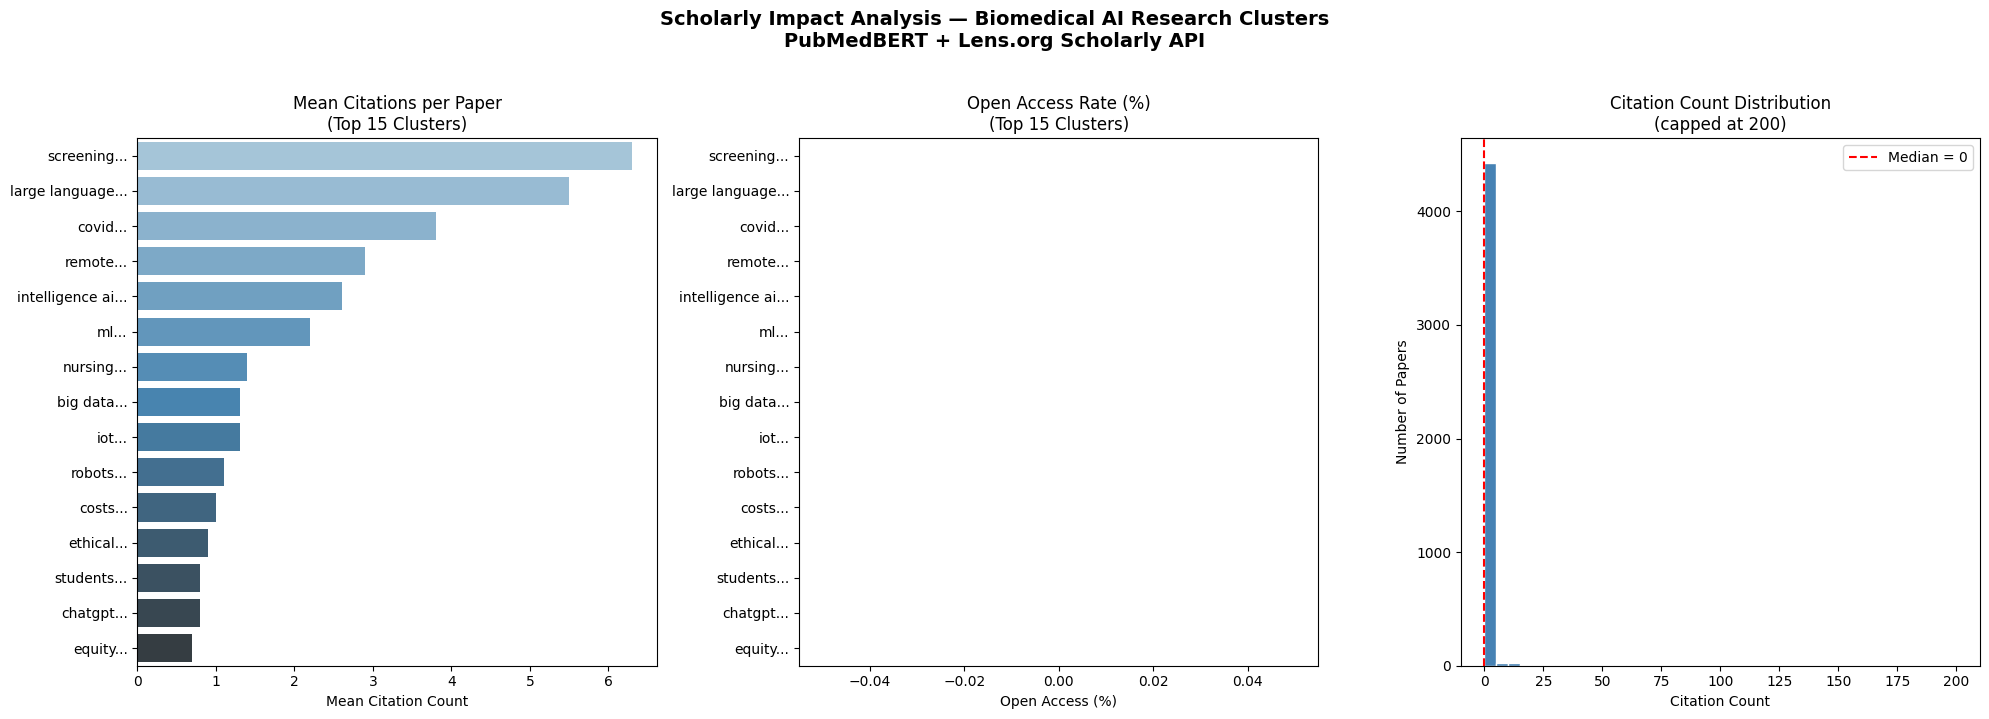

✅ Saved: scholarly_impact_charts.png


In [17]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 14 — THREE PUBLICATION-READY CHARTS                      ║
# ║  Saved as scholarly_impact_charts.png                          ║
# ╚══════════════════════════════════════════════════════════════════╝

citation_by_cluster = pd.read_csv("citation_by_cluster.csv")

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(
    "Scholarly Impact Analysis — Biomedical AI Research Clusters\n"
    "PubMedBERT + Lens.org Scholarly API",
    fontsize=14, fontweight="bold", y=1.02
)

# Chart A — Mean citations per cluster (top 15)
top15 = citation_by_cluster.head(15).copy()
top15["short_label"] = top15["cluster_name"].apply(
    lambda x: x.split("|")[0].strip()[:35] + "..."
)
sns.barplot(data=top15, x="mean_citations", y="short_label",
            palette="Blues_d", ax=axes[0])
axes[0].set_title("Mean Citations per Paper\n(Top 15 Clusters)", fontsize=12)
axes[0].set_xlabel("Mean Citation Count")
axes[0].set_ylabel("")

# Chart B — Open access rate by cluster (top 15)
top15_oa = citation_by_cluster.sort_values(
    "open_access_pct", ascending=False).head(15).copy()
top15_oa["short_label"] = top15_oa["cluster_name"].apply(
    lambda x: x.split("|")[0].strip()[:35] + "..."
)
sns.barplot(data=top15_oa, x="open_access_pct", y="short_label",
            palette="Greens_d", ax=axes[1])
axes[1].set_title("Open Access Rate (%)\n(Top 15 Clusters)", fontsize=12)
axes[1].set_xlabel("Open Access (%)")
axes[1].set_ylabel("")

# Chart C — Citation distribution
axes[2].hist(df["citation_count"].clip(upper=200),
             bins=40, color="steelblue", edgecolor="white")
axes[2].set_title("Citation Count Distribution\n(capped at 200)", fontsize=12)
axes[2].set_xlabel("Citation Count")
axes[2].set_ylabel("Number of Papers")
med = df["citation_count"].median()
axes[2].axvline(med, color="red", linestyle="--", label=f"Median = {med:.0f}")
axes[2].legend()

plt.tight_layout()
plt.savefig("scholarly_impact_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: scholarly_impact_charts.png")

---
## PHASE 7 — PATENT ANALYSIS
*(Run these cells only after Patent API access is granted by Lens.org)*

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 15 — PATENT CITATION CHECK (requires Patent API token)   ║
# ║  Do NOT run until Lens.org grants Patent API access             ║
# ╚══════════════════════════════════════════════════════════════════╝

# Replace with your Patent API token when received:
PATENT_TOKEN = "PASTE_PATENT_TOKEN_HERE"

def check_patent_citation(pmid, token):
    """Returns True if this PubMed paper is cited in any patent."""
    url = "https://api.lens.org/patent/search"
    headers = {"Authorization": f"Bearer {token}",
               "Content-Type": "application/json"}
    body = {
        "query": {"match": {"references.npl_text": str(pmid)}},
        "size": 1, "include": ["lens_id"]
    }
    try:
        r = requests.post(url, json=body, headers=headers, timeout=10)
        return r.json().get("total", 0) > 0
    except:
        return False

# Test on 5 papers first
if PATENT_TOKEN != "PASTE_PATENT_TOKEN_HERE":
    print("Testing patent citation check on 5 papers...")
    for _, row in df.head(5).iterrows():
        result = check_patent_citation(row["pmid"], PATENT_TOKEN)
        print(f"  PMID {row['pmid']}: patent cited = {result}")
        time.sleep(1)
else:
    print("⏳ Patent API token not yet added")
    print("   When Lens.org grants Patent API access:")
    print("   1. Generate a new token on lens.org/lens/user/subscriptions")
    print("   2. Replace PASTE_PATENT_TOKEN_HERE above with your token")
    print("   3. Run this cell, then CELL 16 and CELL 17")

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 16 — RUN PATENT CHECK ON 500-PAPER SAMPLE                ║
# ║  ⏱ Takes ~10 minutes                                            ║
# ╚══════════════════════════════════════════════════════════════════╝

if PATENT_TOKEN == "PASTE_PATENT_TOKEN_HERE":
    print("⏳ Skipping — patent token not yet configured")
else:
    sample_df = df.sample(500, random_state=42).copy()
    patent_cited = []

    for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
        cited = check_patent_citation(row["pmid"], PATENT_TOKEN)
        patent_cited.append(cited)
        time.sleep(1.1)

    sample_df["patent_cited"] = patent_cited
    sample_df.to_csv("sample_with_patents.csv", index=False)

    print(f"\n✅ Done")
    print(f"   Papers with patent citations: {sum(patent_cited)} / 500")
    print(f"   Commercialisation rate: {sum(patent_cited)/500*100:.1f}%")

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 17 — COMMERCIALISATION RATE BY CLUSTER + CHART           ║
# ╚══════════════════════════════════════════════════════════════════╝

if "sample_with_patents.csv" not in os.listdir(PROJECT_DIR):
    print("⏳ Skipping — run CELL 16 first")
else:
    sample_df = pd.read_csv("sample_with_patents.csv")

    conversion = sample_df.groupby("cluster_name").agg(
        n_papers         = ("pmid",         "count"),
        n_commercialized = ("patent_cited",  "sum")
    ).reset_index()
    conversion["conversion_rate_%"] = (
        conversion["n_commercialized"] / conversion["n_papers"] * 100
    ).round(1)
    conversion = conversion.sort_values("conversion_rate_%", ascending=False)

    print(conversion.to_string(index=False))
    conversion.to_csv("conversion_by_cluster.csv", index=False)

    # Bar chart
    plt.figure(figsize=(14, 8))
    top15c = conversion.head(15).copy()
    top15c["short_label"] = top15c["cluster_name"].apply(
        lambda x: x.split("|")[0].strip()[:40] + "..."
    )
    sns.barplot(data=top15c, x="conversion_rate_%", y="short_label", palette="viridis")
    plt.xlabel("Patent Citation Rate (%)", fontsize=13)
    plt.ylabel("Research Cluster", fontsize=13)
    plt.title(
        "Research-to-Commercialisation Rate by Domain\n"
        "PubMedBERT Clustering + Lens.org Patent API (n=500)",
        fontsize=14
    )
    plt.tight_layout()
    plt.savefig("conversion_chart.png", dpi=150)
    plt.show()
    print("✅ Saved: conversion_chart.png")

---
## FINAL CHECK — Confirm all files saved to Drive

In [19]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 18 — VERIFY ALL OUTPUT FILES ON DRIVE                    ║
# ╚══════════════════════════════════════════════════════════════════╝

print(f"Files saved in {PROJECT_DIR}:\n")

expected = {
    "pubmed_corpus.csv":          "Raw corpus — 4,700+ articles",
    "pubmed_embeddings.npy":      "PubMedBERT embeddings matrix",
    "pubmed_corpus_enriched.csv": "Corpus + Lens.org citation data",
    "cluster_report.csv":         "30 clusters with representative papers",
    "cluster_summary.csv":        "Cluster sizes and date ranges",
    "citation_by_cluster.csv":    "Citation impact by research domain",
    "optimal_k.png":              "Silhouette score chart",
    "publications_per_year.png":  "Annual publication trend chart",
    "scholarly_impact_charts.png":"3-panel citation analysis charts",
    "conversion_chart.png":       "Patent conversion rate chart (after patent API)",
}

files_on_drive = os.listdir(PROJECT_DIR)
for fname, description in expected.items():
    if fname in files_on_drive:
        kb = os.path.getsize(fname) / 1024
        print(f"  ✅ {fname:45s} {kb:8.0f} KB   {description}")
    else:
        print(f"  ⏳ {fname:45s}  (not yet generated)")

Files saved in /content/drive/MyDrive/CreativeResearch:

  ✅ pubmed_corpus.csv                                 8750 KB   Raw corpus — 4,700+ articles
  ✅ pubmed_embeddings.npy                            13566 KB   PubMedBERT embeddings matrix
  ✅ pubmed_corpus_enriched.csv                        9256 KB   Corpus + Lens.org citation data
  ✅ cluster_report.csv                                   9 KB   30 clusters with representative papers
  ✅ cluster_summary.csv                                  2 KB   Cluster sizes and date ranges
  ✅ citation_by_cluster.csv                              2 KB   Citation impact by research domain
  ✅ optimal_k.png                                       64 KB   Silhouette score chart
  ✅ publications_per_year.png                           44 KB   Annual publication trend chart
  ✅ scholarly_impact_charts.png                        129 KB   3-panel citation analysis charts
  ⏳ conversion_chart.png                           (not yet generated)
